In [71]:
import warnings

warnings.filterwarnings(
    'ignore',
    message=r'datetime.datetime.utcnow\(\) is deprecated and scheduled for removal in a future version.',
    category=DeprecationWarning
)

In [72]:
import warnings

warnings.filterwarnings('ignore', category=DeprecationWarning)

This code will set a filter to ignore all `DeprecationWarning` messages across your notebook. If you later want to see these warnings again, you can change 'ignore' to 'default' or remove this line.

The code above will suppress the `DeprecationWarning` related to `datetime.datetime.utcnow()` from being displayed in your notebook output.

In [73]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('recom.csv')

# Understand the structure
#print(df.info())
#print(df.describe())
#print(df.head(20))
print('info:')
print(df.info())
print('describe:')
print(df.describe())
print('head:')
print(df.head(100))
print('shape:')
print(df.shape)
print('isnull:')
print(df.isnull().sum())
print('duplicated:')
print(df.duplicated().sum())

# Key questions to investigate:
#- How many unique customers?
#- How many unique items (ItemKey vs Code_Product)?
#- Distribution of purchases per customer?
#- Distribution of purchases per item?
#- How many missing ItemKey values?
#- Date range and temporal patterns?

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      50000 non-null  int64  
 1   Main_ID         50000 non-null  object 
 2   Transaction_ID  50000 non-null  object 
 3   Date            50000 non-null  object 
 4   Price           50000 non-null  float64
 5   Code_Product    50000 non-null  float64
 6   Amount          50000 non-null  float64
 7   ItemKey         28597 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 3.1+ MB
None
describe:
         Unnamed: 0         Price   Code_Product        Amount       ItemKey
count  50000.000000  50000.000000   50000.000000  50000.000000  28597.000000
mean   24999.500000     62.560670   32379.293540      1.232640  20775.740952
std    14433.901067     68.269624   21697.500334      0.749353  16481.882853
min        0.000000      0.500000    5000.500000   

In [74]:
df.head()

,Unnamed: 0,Main_ID,Transaction_ID,Date,Price,Code_Product,Amount,ItemKey
0,0,90fada91,264f7a69,2022-10-07 20:53:49.153,125.0,5002.0,1.0,5002.0
1,1,9006f9ac,45c7d853,2022-09-17 15:54:57.187,19.0,35012.0,1.0,NaN
2,2,32270891,61ad76dd,2022-11-28 13:51:55.667,141.0,5005.0,1.0,5005.0
3,3,97e03e47,41ee09f6,2022-09-12 16:20:22.110,4.5,35078.5,1.0,NaN
4,4,41949228,244fe6d8,2022-10-14 18:53:43.933,129.5,49291.5,5.0,NaN


In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Basic Dataset Information
# -----------------------------

print("Number of rows and columns:", df.shape)
print()

print("Unique Customers:", df["Main_ID"].nunique())
print("Unique Transactions:", df["Transaction_ID"].nunique())
print("Unique ItemKeys:", df["ItemKey"].nunique())
print("Unique Code_Product:", df["Code_Product"].nunique())
print()

# -----------------------------
# Missing ItemKey Values
# -----------------------------

missing_itemkey = df["ItemKey"].isnull().sum()

print("Missing ItemKey Values:", missing_itemkey)
print("Percentage Missing:",
      round((missing_itemkey / len(df)) * 100, 2), "%")

Number of rows and columns: (50000, 8)

Unique Customers: 28514
Unique Transactions: 48403
Unique ItemKeys: 152
Unique Code_Product: 333

Missing ItemKey Values: 21403
Percentage Missing: 42.81 %


count    28514.000000
mean         1.753525
std          2.306502
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         51.000000
dtype: float64


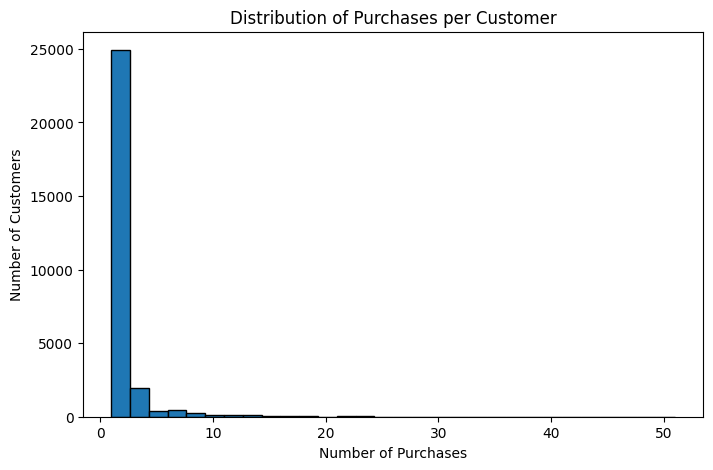

In [76]:
# Count purchases made by each customer
customer_purchases = df.groupby("Main_ID").size()

print(customer_purchases.describe())

plt.figure(figsize=(8,5))
plt.hist(customer_purchases, bins=30, edgecolor="black")
plt.title("Distribution of Purchases per Customer")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

count     152.000000
mean      188.138158
std       457.303601
min         1.000000
25%         7.750000
50%        33.500000
75%       156.250000
max      3814.000000
dtype: float64


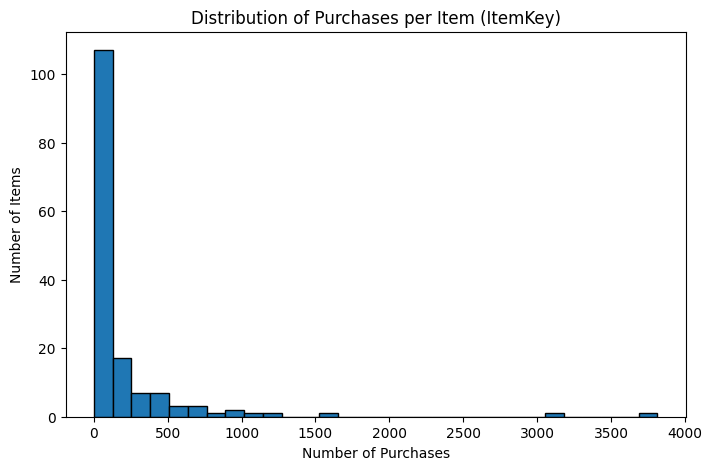

In [77]:
# Count purchases for each ItemKey
item_purchases = df.groupby("ItemKey").size()

print(item_purchases.describe())

plt.figure(figsize=(8,5))
plt.hist(item_purchases, bins=30, edgecolor="black")
plt.title("Distribution of Purchases per Item (ItemKey)")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Items")
plt.show()
#check if an item is frequently purchased by many people or if one customer is buying one item frequently: outlier

count     333.000000
mean      150.150150
std       494.432919
min         1.000000
25%         4.000000
50%        15.000000
75%        83.000000
max      4862.000000
dtype: float64


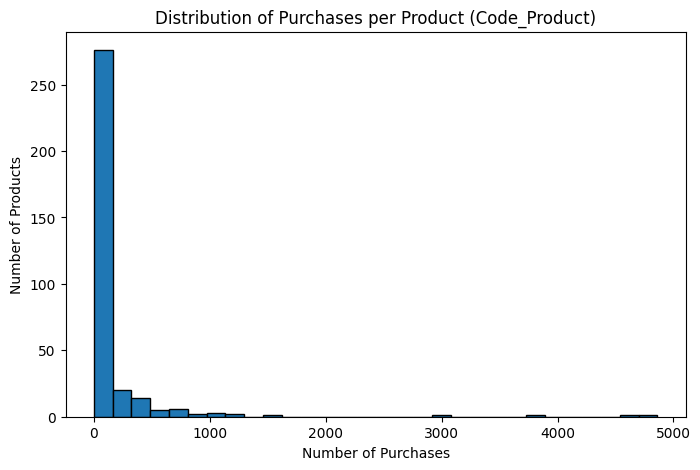

In [78]:
product_purchases = df.groupby("Code_Product").size()

print(product_purchases.describe())

plt.figure(figsize=(8,5))
plt.hist(product_purchases, bins=30, edgecolor="black")
plt.title("Distribution of Purchases per Product (Code_Product)")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Products")
plt.show()

## Outlier Analysis: `Code_Product`

We will investigate two scenarios to identify outliers related to product purchases:

1.  **Products bought frequently by many customers:** This looks for popular products that many distinct customers are buying.
2.  **Products bought often by few customers:** This focuses on customer loyalty or repeat purchases of specific products by a small set of customers.

Distribution of Unique Customers per Product:
count     333.000000
mean      137.840841
std       435.543126
min         1.000000
25%         4.000000
50%        15.000000
75%        76.000000
max      4270.000000
Name: Main_ID, dtype: float64


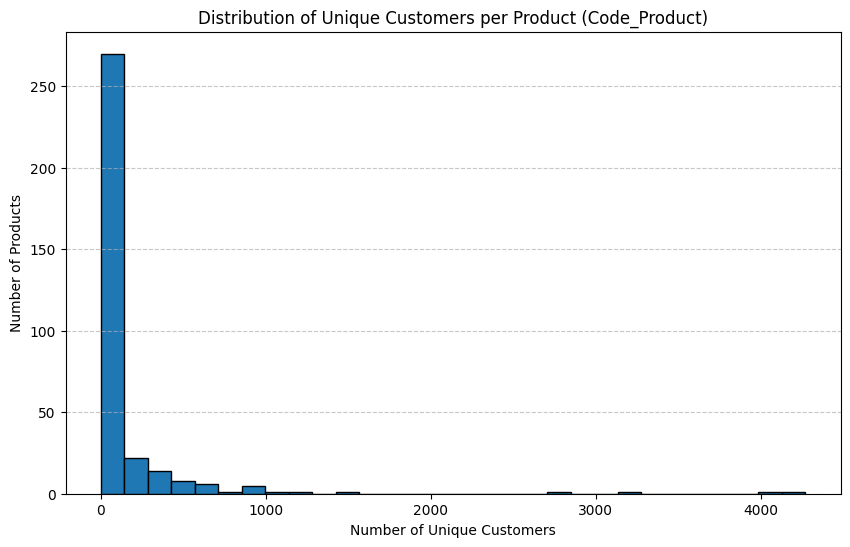


Top 10 Products by Unique Customer Count:
Code_Product
49292.0    4270
49291.5    4127
5000.5     3159
45004.0    2732
10013.0    1454
5009.0     1141
48513.0    1070
48504.5     993
25003.0     969
5011.5      953
Name: Main_ID, dtype: int64


In [79]:
# Scenario 1: Products bought frequently by many customers
# Count unique customers per Code_Product
product_customer_counts = df.groupby('Code_Product')['Main_ID'].nunique()

print("Distribution of Unique Customers per Product:")
print(product_customer_counts.describe())

plt.figure(figsize=(10, 6))
plt.hist(product_customer_counts, bins=30, edgecolor='black')
plt.title('Distribution of Unique Customers per Product (Code_Product)')
plt.xlabel('Number of Unique Customers')
plt.ylabel('Number of Products')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Identify top products by unique customer count
top_products_by_customers = product_customer_counts.nlargest(10)
print("\nTop 10 Products by Unique Customer Count:")
print(top_products_by_customers)


The histogram and the top 10 products indicate which `Code_Product` values are most widely purchased across different customers. Products with a significantly higher number of unique customers compared to the average could be considered popular outliers.

Distribution of Purchase Frequency per Customer-Product Pair:
count    45901.000000
mean         1.089301
std          0.382998
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
dtype: float64


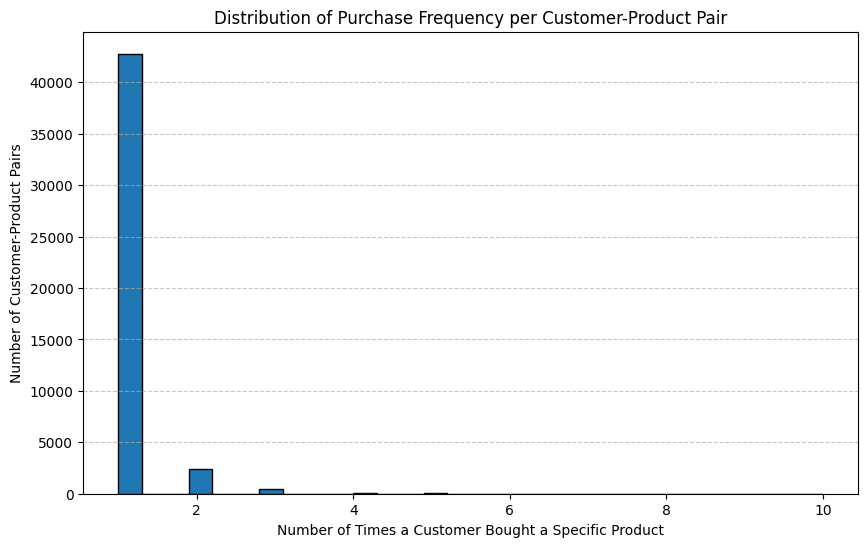


Top 10 Customer-Product Pairs by Purchase Frequency:
Main_ID   Code_Product
9d8b85ad  165016.5        10
0b464fd3  165016.5         9
bef02fe1  5000.5           9
199d7fe7  5000.5           8
751131ee  49291.5          8
7c830a67  5000.5           8
e855363c  5000.5           8
226e8985  5000.5           7
76cc839f  49356.0          7
846c7443  5000.5           7
dtype: int64


In [80]:
# Scenario 2: Products bought often by few customers
# Count how many times each customer buys a specific Code_Product
cust_product_frequency = df.groupby(['Main_ID', 'Code_Product']).size()

print("Distribution of Purchase Frequency per Customer-Product Pair:")
print(cust_product_frequency.describe())

plt.figure(figsize=(10, 6))
plt.hist(cust_product_frequency, bins=30, edgecolor='black')
plt.title('Distribution of Purchase Frequency per Customer-Product Pair')
plt.xlabel('Number of Times a Customer Bought a Specific Product')
plt.ylabel('Number of Customer-Product Pairs')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Identify customer-product pairs with high frequency (outliers)
top_loyal_purchases = cust_product_frequency.nlargest(10)
print("\nTop 10 Customer-Product Pairs by Purchase Frequency:")
print(top_loyal_purchases)


This analysis helps in finding specific products that certain customers purchase repeatedly. High values in the `Purchase Frequency` distribution and the `top_loyal_purchases` can point to 'outlier' customer-product relationships where a few customers are particularly loyal to a specific product.

Products bought frequently by many customers: We identified products like Code_Product 49292.0 and 49291.5 as highly popular items purchased by a large number of unique customers.
Products bought often by few customers: We pinpointed specific customer-product relationships where certain customers show high loyalty by repeatedly purchasing the same product, with some instances of up to 10 purchases.

Earliest Transaction: 2022-08-26 00:00:14.643000
Latest Transaction: 2022-12-03 02:14:57.983000


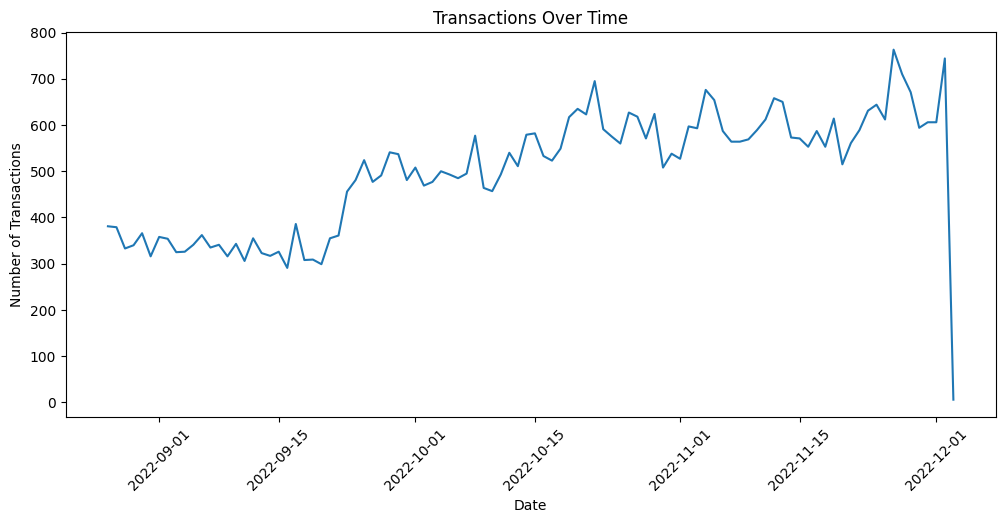

In [81]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

print("Earliest Transaction:", df["Date"].min())
print("Latest Transaction:", df["Date"].max())

# Transactions over time
transactions_per_day = df.groupby(df["Date"].dt.date).size()

plt.figure(figsize=(12,5))
transactions_per_day.plot()
plt.title("Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

In [82]:
print(df[["Code_Product", "ItemKey"]].head(20))

    Code_Product  ItemKey
0         5002.0   5002.0
1        35012.0      NaN
2         5005.0   5005.0
3        35078.5      NaN
4        49291.5      NaN
5        49291.5      NaN
6         5012.0   5012.0
7        49292.0      NaN
8        49292.0      NaN
9         5011.5   5011.5
10        5025.0   5025.0
11       10032.5  10032.5
12        5009.0   5009.0
13       35096.5      NaN
14       40069.5  40069.5
15       45004.0  45004.0
16       48504.5      NaN
17       25003.5  25003.5
18       49291.5      NaN
19        5009.0   5009.0


In [83]:
mapping = df.groupby("Code_Product")["ItemKey"].nunique()

mapping.value_counts()

,count
ItemKey,
0,181
1,152


In [84]:
df.groupby("ItemKey")["Code_Product"].nunique().sort_values(ascending=False).head(20)

,Code_Product
ItemKey,
5000.5,1
5001.0,1
5001.5,1
5002.0,1
5002.5,1
5003.0,1
5004.0,1
5004.5,1
5005.0,1


In [85]:
same = (df["Code_Product"] == df["ItemKey"]) | (df["ItemKey"].isna())

print("All non-missing ItemKeys equal Code_Product:", same.all())

All non-missing ItemKeys equal Code_Product: True


In [86]:
#this will show me how many transactions these users have
customer_purchase_counts = df.groupby("Main_ID").size()
print("# of transactions | customers")
print(customer_purchase_counts
.value_counts().sort_index())

# of transactions | customers
1     21271
2      3647
3      1258
4       718
5       399
6       275
7       189
8       143
9        94
10       99
11       66
12       53
13       48
14       44
15       39
16       21
17       27
18       20
19       16
20       15
21        7
22       13
23       10
24        8
25        5
26        5
27        4
28        3
29        2
30        1
31        4
32        1
33        1
35        1
36        4
39        1
47        1
51        1
Name: count, dtype: int64


Based on the above results, I don't think I should remove any users. 21271 users have only 1 transaction and that is about 75% of the dataset if I removed them

## User-Item Matrix Creation

To create a user-item matrix, we'll use `Main_ID` as the users and `Code_Product` as the items. The values in the matrix will represent the number of times each user has purchased a specific product. This is a common representation for recommendation systems.

In [87]:
# Create the user-item interaction matrix using purchase frequency.
# essentially this matrix shows how often a customer buys a certain item across all transaction.

user_item_matrix = df.pivot_table(
    index="Main_ID",
    columns="Code_Product",
    values="Transaction_ID",
    aggfunc="count",
    fill_value=0
)

print("User-Item Matrix Shape:", user_item_matrix.shape)
user_item_matrix.head()


User-Item Matrix Shape: (28514, 333)


Code_Product,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200035.5,200037.0,200037.5,200038.0,200038.5,200045.5,200046.0,200046.5,200047.0,350027.5
Main_ID,,,,,,,,,,,,,,,,,,,,,
00024de6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00084856,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0008e848,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00096930,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000c66b7,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



so it only shows the number of times a user bought an item while not distinguishing if they bought those items in different transactions?


That's a very important clarification! The user_item_matrix you currently have, created with aggfunc='count' on Transaction_ID, counts the number of distinct line items for each Main_ID (customer) and Code_Product (product).

Let me break this down:

It does distinguish items bought in different transactions: If a customer buys Product P in Transaction X (resulting in one row in your original df) and then buys Product P again in Transaction Y (another row in df), both of these separate purchase events will be counted, leading to a value of 2 in the user-item matrix for (Customer, Product P).
It does not sum the Amount (quantity) column: If a customer buys 5 units of Product P in a single transaction (represented by one row in df where Amount is 5), the aggfunc='count' will still only count this as 1 because it's a single line item in the original DataFrame. It does not multiply by the Amount.
So, the matrix currently shows the number of times a customer had a line item for a particular product, which inherently includes distinctions for purchases across different transactions.

If you want to calculate something different:
To get the total quantity of each product a user bought: You would use aggfunc='sum' on the Amount column.
user_item_matrix_quantity = df.pivot_table(
    index="Main_ID",
    columns="Code_Product",
    values="Amount",
    aggfunc="sum",
    fill_value=0
)
To get the number of unique transactions in which a user bought a product: You would use aggfunc='nunique' on the Transaction_ID column.
user_item_matrix_unique_transactions = df.pivot_table(
    index="Main_ID",
    columns="Code_Product",
    values="Transaction_ID",
    aggfunc="nunique",
    fill_value=0
)
Which of these interpretations aligns best with what you're trying to achieve?

In [88]:
#checking out the matrix sparsity
print("Number of customers:", user_item_matrix.shape[0])
print("Number of products:", user_item_matrix.shape[1])

print("\nFirst five rows:")
display(user_item_matrix.head())

print("\nMatrix sparsity:")
non_zero = (user_item_matrix > 0).sum().sum()
total = user_item_matrix.size

print(f"Non-zero entries: {non_zero:,}")
print(f"Total entries: {total:,}")
print(f"Sparsity: {(1 - non_zero / total) * 100:.2f}%")

Number of customers: 28514
Number of products: 333

First five rows:


Code_Product,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200035.5,200037.0,200037.5,200038.0,200038.5,200045.5,200046.0,200046.5,200047.0,350027.5
Main_ID,,,,,,,,,,,,,,,,,,,,,
00024de6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00084856,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0008e848,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00096930,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000c66b7,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Matrix sparsity:
Non-zero entries: 45,901
Total entries: 9,495,162
Sparsity: 99.52%


## Implicit Rating Approaches

We will create two different user-item matrices based on implicit feedback:

1.  **Frequency-based**: The rating represents the number of times a user has purchased a specific product.
2.  **Spending-based**: The rating represents the total amount of money a user has spent on a specific product.

### 1. Frequency-Based Implicit Ratings

This matrix `user_item_frequency_matrix` will represent how many times each `Main_ID` (customer) has purchased each `Code_Product`.

In [89]:
# Rename the previously created user_item_matrix for clarity as it is frequency-based
user_item_frequency_matrix = user_item_matrix.copy()

print("User-Item Frequency Matrix Shape:", user_item_frequency_matrix.shape)
print("First 5 rows of Frequency Matrix:")
display(user_item_frequency_matrix.head())

User-Item Frequency Matrix Shape: (28514, 333)
First 5 rows of Frequency Matrix:


Code_Product,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200035.5,200037.0,200037.5,200038.0,200038.5,200045.5,200046.0,200046.5,200047.0,350027.5
Main_ID,,,,,,,,,,,,,,,,,,,,,
00024de6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00084856,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0008e848,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00096930,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000c66b7,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 2. Spending-Based Implicit Ratings

This matrix `user_item_spending_matrix` will represent the total monetary amount (`Price * Amount`) each `Main_ID` (customer) has spent on each `Code_Product`.

In [90]:
# Calculate the total spending for each line item
df['Total_Spent'] = df['Price'] * df['Amount']

# Create the user-item spending matrix
user_item_spending_matrix = df.pivot_table(
    index="Main_ID",
    columns="Code_Product",
    values="Total_Spent",
    aggfunc="sum",
    fill_value=0
)

print("User-Item Spending Matrix Shape:", user_item_spending_matrix.shape)
print("First 5 rows of Spending Matrix:")
display(user_item_spending_matrix.head())

User-Item Spending Matrix Shape: (28514, 333)
First 5 rows of Spending Matrix:


Code_Product,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200035.5,200037.0,200037.5,200038.0,200038.5,200045.5,200046.0,200046.5,200047.0,350027.5
Main_ID,,,,,,,,,,,,,,,,,,,,,
00024de6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00084856,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0008e848,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00096930,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
000c66b7,0.0,0.0,0.0,31.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


4.3 Part 3: Comparative Implementation

In [91]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

# Install mlxtend for association rules if not already installed
try:
    import mlxtend
except ImportError:
    print("mlxtend not found. Installing...")
    !pip install mlxtend
    import mlxtend

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

### 4.3 Part 3: Comparative Implementation

## 1. Popularity-Based Baseline Recommendation

# This is the simplest recommendation approach. It recommends items that are most frequently purchased across all users. It serves as a good baseline to compare against more complex, personalized methods.

# Calculate item popularity from the frequency matrix
item_popularity = user_item_frequency_matrix.sum(axis=0).sort_values(ascending=False)

def get_popularity_recommendations(num_recommendations=5):
    """
    Generates popularity-based recommendations.
    """
    return item_popularity.head(num_recommendations).index.tolist()

print("Top 10 Popular Items:")
print(get_popularity_recommendations(10))

## 2. Item-Based Collaborative Filtering

# Item-based collaborative filtering recommends items based on their similarity to items a user has already liked or purchased. The assumption is that if a user bought item A, and item A is similar to item B, the user might also like item B.

# Calculate item-item similarity using cosine similarity
# Transpose the matrix to get items as rows and users as columns
item_user_matrix = user_item_frequency_matrix.T

# Convert to sparse matrix for efficient similarity calculation
item_user_sparse = csr_matrix(item_user_matrix)

# Compute cosine similarity between items
# This can be computationally intensive for very large matrices
item_similarity = cosine_similarity(item_user_sparse)

# Convert to DataFrame for easier indexing
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

print("Item-Item Similarity Matrix Shape:", item_similarity_df.shape)
print("First 5x5 of Item Similarity Matrix:")
display(item_similarity_df.head())

def get_item_based_recommendations(
    user_id,
    user_item_matrix,
    item_similarity_df,
    num_recommendations=5
):
    """
    Generates item-based collaborative filtering recommendations for a given user.
    """
    # Get items the user has already interacted with
    user_purchased_items = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index

    if user_purchased_items.empty:
        return get_popularity_recommendations(num_recommendations) # Fallback to popularity

    # Aggregate similarity scores for all items based on user's purchased items
    item_scores = pd.Series(0.0, index=item_similarity_df.index)
    for item in user_purchased_items:
        if item in item_similarity_df.index:
            item_scores += item_similarity_df[item]

    # Remove items already purchased by the user
    item_scores = item_scores.drop(user_purchased_items, errors='ignore')

    # Sort items by score and return top N
    recommended_items = item_scores.sort_values(ascending=False).head(num_recommendations).index.tolist()

    return recommended_items

# Example for a sample user
sample_user_id = user_item_frequency_matrix.index[0] # Pick the first user
print(f"\nItems purchased by user {sample_user_id}:", user_item_frequency_matrix.loc[sample_user_id][user_item_frequency_matrix.loc[sample_user_id] > 0].index.tolist())
print(f"Item-Based Recommendations for user {sample_user_id}:", get_item_based_recommendations(sample_user_id, user_item_frequency_matrix, item_similarity_df))

## 3. Advanced Approach: Association Rules (Market Basket Analysis)

# Association rules discover relationships between items, often phrased as "if a user buys X, they also tend to buy Y." This is particularly useful for "frequently bought together" recommendations.

# Prepare data for Apriori: list of transactions, where each transaction is a list of items
# We'll consider any purchase (frequency > 0) as an item in the basket

# Create a list of lists, where each inner list contains products bought by a single customer
transactions_list = []
for i in range(user_item_frequency_matrix.shape[0]):
    user_items = user_item_frequency_matrix.iloc[i][user_item_frequency_matrix.iloc[i] > 0].index.tolist()
    if user_items: # Only add if the user has purchased items
        transactions_list.append(user_items)

# Use TransactionEncoder to convert the list of lists into a one-hot encoded DataFrame
te = TransactionEncoder()
te_ary = te.fit(transactions_list).transform(transactions_list)
df_transactions = pd.DataFrame(te_ary, columns=te.columns_)

print("Shape of transaction encoded DataFrame:", df_transactions.shape)
print("First 5 rows of transaction encoded DataFrame:")
display(df_transactions.head())

# Find frequent itemsets using Apriori algorithm
frequent_itemsets = apriori(df_transactions, min_support=0.01, use_colnames=True) # min_support can be adjusted

print("\nFrequent Itemsets (first 5):")
display(frequent_itemsets.head())

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2) # min_threshold can be adjusted
rules = rules.sort_values(['lift'], ascending=False).reset_index(drop=True)

print("\nAssociation Rules (top 5 by lift):")
display(rules.head())

def get_association_rule_recommendations(
    user_id,
    user_item_matrix,
    rules,
    num_recommendations=5
):
    """
    Generates association rule-based recommendations for a given user.
    """
    user_purchased_items = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index

    if user_purchased_items.empty:
        return get_popularity_recommendations(num_recommendations) # Fallback to popularity

    # Find rules where the antecedent (if part) is in the user's purchased items
    recommendations = set()
    for purchased_item in user_purchased_items:
        matching_rules = rules[rules['antecedents'].apply(lambda x: purchased_item in x)]
        for _, row in matching_rules.iterrows():
            for item in row['consequents']:
                if item not in user_purchased_items: # Only recommend items not already bought
                    recommendations.add(item)

    # Prioritize by lift or confidence of the rules
    # For simplicity, we'll just take the top N unique items found
    return list(recommendations)[:num_recommendations]

# Example for a sample user
sample_user_id = user_item_frequency_matrix.index[0] # Pick the first user
print(f"\nItems purchased by user {sample_user_id}:", user_item_frequency_matrix.loc[sample_user_id][user_item_frequency_matrix.loc[sample_user_id] > 0].index.tolist())
print(f"Association Rule Recommendations for user {sample_user_id}:", get_association_rule_recommendations(sample_user_id, user_item_frequency_matrix, rules))

# Now that the recommendation functions are implemented, we can move to evaluation in a later step.

Top 10 Popular Items:
[49292.0, 49291.5, 5000.5, 45004.0, 10013.0, 5009.0, 48513.0, 48504.5, 25003.0, 5011.5]
Item-Item Similarity Matrix Shape: (333, 333)
First 5x5 of Item Similarity Matrix:


Code_Product,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200035.5,200037.0,200037.5,200038.0,200038.5,200045.5,200046.0,200046.5,200047.0,350027.5
Code_Product,,,,,,,,,,,,,,,,,,,,,
5000.5,1.000000,0.191281,0.132201,0.170314,0.0,0.013488,0.003334,0.066335,0.065775,0.043908,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5001.0,0.191281,1.000000,0.061417,0.133634,0.0,0.006876,0.000000,0.041405,0.105375,0.039498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5001.5,0.132201,0.061417,1.000000,0.053683,0.0,0.015038,0.011152,0.013584,0.031428,0.025916,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5002.0,0.170314,0.133634,0.053683,1.000000,0.0,0.012020,0.000000,0.043429,0.046053,0.013810,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5002.5,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Items purchased by user 00024de6: [35097.0]
Item-Based Recommendations for user 00024de6: [35049.0, 35001.0, 35096.5, 30026.5, 35079.5]
Shape of transaction encoded DataFrame: (28514, 333)
First 5 rows of transaction encoded DataFrame:


,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200035.5,200037.0,200037.5,200038.0,200038.5,200045.5,200046.0,200046.5,200047.0,350027.5
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



Frequent Itemsets (first 5):


,support,itemsets
0,0.110788,(5000.5)
1,0.016904,(5001.0)
2,0.016167,(5001.5)
3,0.023147,(5002.0)
4,0.040015,(5009.0)



Association Rules (top 5 by lift):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(5000.5),(45004.0),0.110788,0.095813,0.014449,0.130421,1.36121,1.0,0.003834,1.039799,0.298421,0.075196,0.038276,0.140613
1,(45004.0),(5000.5),0.095813,0.110788,0.014449,0.150805,1.36121,1.0,0.003834,1.047124,0.293478,0.075196,0.045003,0.140613



Items purchased by user 00024de6: [35097.0]
Association Rule Recommendations for user 00024de6: []


THis is where I start doing the train test split and retraining the models

# Task
The primary goal is to implement and comparatively evaluate three recommendation system approaches: Popularity-Based Baseline, Item-Based Collaborative Filtering, and Association Rules. This will involve splitting the data into training and testing sets, building user-item matrices from the training data, re-implementing the recommendation models, defining appropriate evaluation metrics, and finally evaluating and comparing the performance of each model on the test data. The outcome will be a clear understanding of the strengths and weaknesses of each recommendation strategy.

## Implement Temporal Train-Test Split

### Subtask:
Sort the entire dataset by `Date` and then split it into training and testing sets for each user. Ensure earlier transactions are in the training set and later transactions are in the testing set, aiming for an approximate 80% train and 20% test split. Handle users with only one purchase appropriately.


**Reasoning**:
First, sort the DataFrame by the 'Date' column as instructed. Then, I will process each user to split their transactions.



In [92]:
df_sorted = df.sort_values(by='Date').reset_index(drop=True)
print("DataFrame sorted by Date:")
print(df_sorted.head())

DataFrame sorted by Date:
   Unnamed: 0   Main_ID Transaction_ID                    Date  Price  \
0       16726  fd791c5f       b74dd1cc 2022-08-26 00:00:14.643  238.0   
1       18537  1283bee8       5c4f8c08 2022-08-26 07:32:34.807  483.0   
2       20151  92113dd4       87a673d9 2022-08-26 08:55:12.440    6.5   
3       34420  bedecec3       f1081001 2022-08-26 10:41:07.863   29.0   
4       31311  b663568c       cde97e07 2022-08-26 10:50:50.303   41.0   

   Code_Product  Amount  ItemKey  Total_Spent  
0       49567.5     1.0      NaN        238.0  
1       10023.0     1.0  10023.0        483.0  
2      200019.5     1.0      NaN          6.5  
3        5011.5     1.0   5011.5         29.0  
4       49567.5     1.0      NaN         41.0  


**Reasoning**:
I will group the sorted DataFrame by `Main_ID` and apply a function to each group to split the transactions into train and test sets, handling single-transaction users by placing their sole transaction in the training set.



In [93]:
train_data = []
test_data = []

for user_id, group in df_sorted.groupby('Main_ID'):
    num_transactions = len(group)
    if num_transactions == 1:
        train_data.append(group)
    else:
        split_point = int(0.8 * num_transactions)
        train_data.append(group.iloc[:split_point])
        test_data.append(group.iloc[split_point:])

train_df = pd.concat(train_data).reset_index(drop=True)
test_df = pd.concat(test_data).reset_index(drop=True)

print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")

print("\nFirst 5 rows of Training DataFrame:")
print(train_df.head())

print("\nFirst 5 rows of Testing DataFrame:")
print(test_df.head())

Training set shape: (40817, 9)
Testing set shape: (9183, 9)

First 5 rows of Training DataFrame:
   Unnamed: 0   Main_ID Transaction_ID                    Date  Price  \
0       31628  00024de6       9016611c 2022-09-03 15:12:52.607    6.0   
1       37021  00084856       3a8c5a03 2022-10-21 16:40:07.373   24.0   
2       18346  0008e848       382c1a6b 2022-09-13 19:34:10.853   13.0   
3        3927  00096930       3bc7a8f5 2022-11-25 20:13:57.747   48.0   
4       36474  000c66b7       9a4b4d33 2022-09-06 13:20:25.257   31.0   

   Code_Product  Amount  ItemKey  Total_Spent  
0       35097.0     2.0      NaN         12.0  
1       49292.0     1.0      NaN         24.0  
2       40002.0     1.0      NaN         13.0  
3       49291.5     2.0      NaN         96.0  
4        5002.0     1.0   5002.0         31.0  

First 5 rows of Testing DataFrame:
   Unnamed: 0   Main_ID Transaction_ID                    Date  Price  \
0       37004  00084856       cb1b492d 2022-11-05 15:08:11.743   22

## Rebuild User-Item Matrices on Training Data

Now, we will create the `user_item_frequency_matrix_train` and `user_item_spending_matrix_train` using only the `train_df`.

In [94]:
# Create the user-item frequency matrix for the training set
user_item_frequency_matrix_train = train_df.pivot_table(
    index='Main_ID',
    columns='Code_Product',
    values='Transaction_ID',
    aggfunc='count',
    fill_value=0
)

print("Train User-Item Frequency Matrix Shape:", user_item_frequency_matrix_train.shape)
print("First 5 rows of Train Frequency Matrix:")
display(user_item_frequency_matrix_train.head())

Train User-Item Frequency Matrix Shape: (28514, 320)
First 5 rows of Train Frequency Matrix:


Code_Product,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200028.0,200029.0,200035.5,200037.0,200037.5,200045.5,200046.0,200046.5,200047.0,350027.5
Main_ID,,,,,,,,,,,,,,,,,,,,,
00024de6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00084856,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0008e848,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00096930,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000c66b7,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [95]:
# The 'Total_Spent' column should already exist in train_df from the previous step
# If it doesn't, uncomment the line below:
# train_df['Total_Spent'] = train_df['Price'] * train_df['Amount']

# Create the user-item spending matrix for the training set
user_item_spending_matrix_train = train_df.pivot_table(
    index='Main_ID',
    columns='Code_Product',
    values='Total_Spent',
    aggfunc='sum',
    fill_value=0
)

print("\nTrain User-Item Spending Matrix Shape:", user_item_spending_matrix_train.shape)
print("First 5 rows of Train Spending Matrix:")
display(user_item_spending_matrix_train.head())


Train User-Item Spending Matrix Shape: (28514, 320)
First 5 rows of Train Spending Matrix:


Code_Product,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200028.0,200029.0,200035.5,200037.0,200037.5,200045.5,200046.0,200046.5,200047.0,350027.5
Main_ID,,,,,,,,,,,,,,,,,,,,,
00024de6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00084856,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0008e848,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00096930,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
000c66b7,0.0,0.0,0.0,31.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Rebuild User-Item Matrices on Test Data

Next, we will create `user_item_frequency_matrix_test` and `user_item_spending_matrix_test` using only the `test_df`.

In [96]:
# Create the user-item frequency matrix for the testing set
user_item_frequency_matrix_test = test_df.pivot_table(
    index='Main_ID',
    columns='Code_Product',
    values='Transaction_ID',
    aggfunc='count',
    fill_value=0
)

print("Test User-Item Frequency Matrix Shape:", user_item_frequency_matrix_test.shape)
print("First 5 rows of Test Frequency Matrix:")
display(user_item_frequency_matrix_test.head())

Test User-Item Frequency Matrix Shape: (7243, 268)
First 5 rows of Test Frequency Matrix:


Code_Product,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200022.0,200025.0,200029.0,200035.5,200037.0,200037.5,200038.0,200038.5,200045.5,200046.0
Main_ID,,,,,,,,,,,,,,,,,,,,,
00084856,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000c66b7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000e98ee,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0019e439,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
001ef3e0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [97]:
# The 'Total_Spent' column should already exist in test_df from the previous step
# If it doesn't, uncomment the line below:
# test_df['Total_Spent'] = test_df['Price'] * test_df['Amount']

# Create the user-item spending matrix for the testing set
user_item_spending_matrix_test = test_df.pivot_table(
    index='Main_ID',
    columns='Code_Product',
    values='Total_Spent',
    aggfunc='sum',
    fill_value=0
)

print("\nTest User-Item Spending Matrix Shape:", user_item_spending_matrix_test.shape)
print("First 5 rows of Test Spending Matrix:")
display(user_item_spending_matrix_test.head())


Test User-Item Spending Matrix Shape: (7243, 268)
First 5 rows of Test Spending Matrix:


Code_Product,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200022.0,200025.0,200029.0,200035.5,200037.0,200037.5,200038.0,200038.5,200045.5,200046.0
Main_ID,,,,,,,,,,,,,,,,,,,,,
00084856,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
000c66b7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
000e98ee,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0019e439,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
001ef3e0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Re-implement Recommendation Models with Training Data

Now we will re-implement the three recommendation approaches (Popularity-Based Baseline, Item-Based Collaborative Filtering, and Association Rules) using only the training data (`train_df` and the derived training user-item matrices).

### 1. Popularity-Based Baseline Recommendation (Training Data)

We'll calculate item popularity based on `user_item_frequency_matrix_train`.

In [98]:
# Calculate item popularity from the training frequency matrix
item_popularity_train = user_item_frequency_matrix_train.sum(axis=0).sort_values(ascending=False)

def get_popularity_recommendations_train(num_recommendations=5):
    """
    Generates popularity-based recommendations using training data.
    """
    return item_popularity_train.head(num_recommendations).index.tolist()

print("Top 10 Popular Items (Training Data):")
print(get_popularity_recommendations_train(10))

Top 10 Popular Items (Training Data):
[49292.0, 49291.5, 5000.5, 45004.0, 10013.0, 5009.0, 48513.0, 25003.0, 48504.5, 5011.5]


### 2. Item-Based Collaborative Filtering (Training Data)

Now, we'll re-implement Item-Based Collaborative Filtering using `user_item_frequency_matrix_train`.

In [99]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

# Calculate item-item similarity using cosine similarity on the training frequency matrix
# Transpose the matrix to get items as rows and users as columns
item_user_matrix_train = user_item_frequency_matrix_train.T

# Convert to sparse matrix for efficient similarity calculation
item_user_sparse_train = csr_matrix(item_user_matrix_train)

# Compute cosine similarity between items
item_similarity_df_train = pd.DataFrame(
    cosine_similarity(item_user_sparse_train),
    index=item_user_matrix_train.index,
    columns=item_user_matrix_train.index
)

print("Item-Item Similarity Matrix (Training Data) Shape:", item_similarity_df_train.shape)
print("First 5x5 of Item Similarity Matrix (Training Data):")
display(item_similarity_df_train.head())

def get_item_based_recommendations_train(
    user_id,
    user_item_matrix_train,
    item_similarity_df_train,
    num_recommendations=5
):
    """
    Generates item-based collaborative filtering recommendations for a given user using training data.
    """
    # Get items the user has already interacted with in the training set
    user_purchased_items_train = user_item_matrix_train.loc[user_id][user_item_matrix_train.loc[user_id] > 0].index

    if user_purchased_items_train.empty:
        # Fallback to popularity if the user has no training purchases
        return get_popularity_recommendations_train(num_recommendations)

    # Aggregate similarity scores for all items based on user's purchased items
    item_scores = pd.Series(0.0, index=item_similarity_df_train.index)
    for item in user_purchased_items_train:
        if item in item_similarity_df_train.index:
            item_scores += item_similarity_df_train[item]

    # Remove items already purchased by the user in the training set
    item_scores = item_scores.drop(user_purchased_items_train, errors='ignore')

    # Sort items by score and return top N
    recommended_items = item_scores.sort_values(ascending=False).head(num_recommendations).index.tolist()

    return recommended_items

# Example for a sample user (first user in the training matrix)
sample_user_id_train = user_item_frequency_matrix_train.index[0]
print(f"\nItems purchased by user {sample_user_id_train} (Training Data):", user_item_frequency_matrix_train.loc[sample_user_id_train][user_item_frequency_matrix_train.loc[sample_user_id_train] > 0].index.tolist())
print(f"Item-Based Recommendations for user {sample_user_id_train} (Training Data):", get_item_based_recommendations_train(sample_user_id_train, user_item_frequency_matrix_train, item_similarity_df_train))

Item-Item Similarity Matrix (Training Data) Shape: (320, 320)
First 5x5 of Item Similarity Matrix (Training Data):


Code_Product,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200028.0,200029.0,200035.5,200037.0,200037.5,200045.5,200046.0,200046.5,200047.0,350027.5
Code_Product,,,,,,,,,,,,,,,,,,,,,
5000.5,1.000000,0.145229,0.096690,0.133689,0.0,0.008879,0.0,0.044103,0.043548,0.031754,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5001.0,0.145229,1.000000,0.036906,0.101989,0.0,0.008572,0.0,0.030657,0.090094,0.020438,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5001.5,0.096690,0.036906,1.000000,0.037827,0.0,0.018759,0.0,0.011181,0.019715,0.022362,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5002.0,0.133689,0.101989,0.037827,1.000000,0.0,0.014937,0.0,0.035612,0.031397,0.008903,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5002.5,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Items purchased by user 00024de6 (Training Data): [35097.0]
Item-Based Recommendations for user 00024de6 (Training Data): [35001.0, 35096.5, 30026.5, 35078.5, 40021.5]


### 3. Advanced Approach: Association Rules (Market Basket Analysis) (Training Data)

We'll re-implement association rules using `user_item_frequency_matrix_train`.

In [104]:
try:
    import mlxtend
except ImportError:
    print("mlxtend not found. Installing...")
    !pip install mlxtend
    import mlxtend

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Prepare data for Apriori using the training frequency matrix
transactions_list_train = []
for i in range(user_item_frequency_matrix_train.shape[0]):
    user_items_train = user_item_frequency_matrix_train.iloc[i][user_item_frequency_matrix_train.iloc[i] > 0].index.tolist()
    if user_items_train: # Only add if the user has purchased items in the training set
        transactions_list_train.append(user_items_train)

# Use TransactionEncoder to convert the list of lists into a one-hot encoded DataFrame
te_train = TransactionEncoder()
te_ary_train = te_train.fit(transactions_list_train).transform(transactions_list_train)
df_transactions_train = pd.DataFrame(te_ary_train, columns=te_train.columns_)

print("Shape of transaction encoded DataFrame (Training Data):", df_transactions_train.shape)
print("First 5 rows of transaction encoded DataFrame (Training Data):")
display(df_transactions_train.head())

# Find frequent itemsets using Apriori algorithm
frequent_itemsets_train = apriori(df_transactions_train, min_support=0.001, use_colnames=True) # min_support adjusted

print("\nFrequent Itemsets (Training Data, first 5):")
display(frequent_itemsets_train.head())

# Generate association rules
rules_train = association_rules(frequent_itemsets_train, metric="lift", min_threshold=1.0) # min_threshold adjusted
rules_train = rules_train.sort_values(['lift'], ascending=False).reset_index(drop=True)

print("\nAssociation Rules (Training Data, top 5 by lift):")
display(rules_train.head())

# Re-introduce Pre-processing rules for faster lookup based on individual antecedent items
# Create a dictionary where keys are individual items and values are lists of rules where that item is an antecedent
rules_lookup = {}
for idx, row in rules_train.iterrows():
    for item in row['antecedents']:
        if item not in rules_lookup:
            rules_lookup[item] = []
        # Store the entire rule row or relevant parts to rank later
        rules_lookup[item].append({'consequents': row['consequents'], 'lift': row['lift']})

def get_association_rule_recommendations_train(
    user_id,
    user_item_matrix_train,
    rules_lookup_dict, # Now expects the rules_lookup dictionary
    num_recommendations=5
):
    """
    Generates association rule-based recommendations for a given user using training data.
    Recommendations are based on individual items purchased by the user being part of an antecedent.
    """
    user_purchased_items_train = user_item_matrix_train.loc[user_id][user_item_matrix_train.loc[user_id] > 0].index.tolist()
    user_purchased_items_train_set = frozenset(user_purchased_items_train) # Convert to frozenset for efficient checking

    if not user_purchased_items_train_set:
        return get_popularity_recommendations_train(num_recommendations) # Fallback to popularity

    recommendations_with_scores = {} # Store consequent and its score (e.g., lift) for ranking

    for purchased_item in user_purchased_items_train_set:
        if purchased_item in rules_lookup_dict:
            for rule_info in rules_lookup_dict[purchased_item]:
                consequents = rule_info['consequents']
                lift = rule_info['lift']

                for item_to_recommend in consequents:
                    # Ensure we don't recommend items the user already bought
                    if item_to_recommend not in user_purchased_items_train_set:
                        # Keep the highest lift if an item can be recommended by multiple rules
                        if item_to_recommend not in recommendations_with_scores or lift > recommendations_with_scores[item_to_recommend]:
                            recommendations_with_scores[item_to_recommend] = lift

    # Sort recommendations by score (lift) in descending order
    sorted_recommendations = sorted(recommendations_with_scores.items(), key=lambda x: x[1], reverse=True)

    # Extract only the item Code_Product
    recommended_items = [item for item, _ in sorted_recommendations]

    return recommended_items[:num_recommendations]

# Example for a sample user (first user in the training matrix)
sample_user_id_train = user_item_frequency_matrix_train.index[10]
print(f"\nItems purchased by user {sample_user_id_train} (Training Data):", user_item_frequency_matrix_train.loc[sample_user_id_train][user_item_frequency_matrix_train.loc[sample_user_id_train] > 0].index.tolist())
print(f"Association Rule Recommendations for user {sample_user_id_train} (Training Data):", get_association_rule_recommendations_train(sample_user_id_train, user_item_frequency_matrix_train, rules_lookup))

Shape of transaction encoded DataFrame (Training Data): (28514, 320)
First 5 rows of transaction encoded DataFrame (Training Data):


,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200028.0,200029.0,200035.5,200037.0,200037.5,200045.5,200046.0,200046.5,200047.0,350027.5
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



Frequent Itemsets (Training Data, first 5):


,support,itemsets
0,0.095181,(5000.5)
1,0.014344,(5001.0)
2,0.013327,(5001.5)
3,0.019359,(5002.0)
4,0.002350,(5004.5)



Association Rules (Training Data, top 5 by lift):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(48513.0, 49292.0)","(5000.5, 49291.5)",0.003507,0.009329,0.001227,0.350000,37.518421,1.0,0.001195,1.524110,0.976772,0.105740,0.343879,0.240789
1,"(5000.5, 49291.5)","(48513.0, 49292.0)",0.009329,0.003507,0.001227,0.131579,37.518421,1.0,0.001195,1.147477,0.982512,0.105740,0.128523,0.240789
2,"(5000.5, 49292.0)","(48513.0, 49291.5)",0.009329,0.003753,0.001227,0.131579,35.063945,1.0,0.001192,1.147194,0.980629,0.103550,0.128308,0.229341
3,"(48513.0, 49291.5)","(5000.5, 49292.0)",0.003753,0.009329,0.001227,0.327103,35.063945,1.0,0.001192,1.472248,0.975140,0.103550,0.320766,0.229341
4,"(5000.5, 49292.0)","(49291.5, 10013.0)",0.009329,0.004244,0.001227,0.131579,31.006960,1.0,0.001188,1.146629,0.976862,0.099432,0.127878,0.210418



Items purchased by user 001b1dab (Training Data): [5000.5]
Association Rule Recommendations for user 001b1dab (Training Data): [48513.0, 49292.0, 49291.5, 10013.0, 45004.0]


## Define Evaluation Metrics

To evaluate the performance of our recommendation models, especially in the context of implicit feedback and a temporal split, we'll focus on metrics that assess how well the models predict future purchases. Key metrics for this scenario include:

1.  **Precision@k**: The proportion of recommended items at rank `k` that are relevant (i.e., actually purchased by the user in the test set).
2.  **Recall@k**: The proportion of relevant items in the test set that are found in the top `k` recommendations.
3.  **F1-score@k**: The harmonic mean of Precision@k and Recall@k, providing a single metric that balances both.
4.  **Mean Average Precision (MAP@k)**: A popular metric that considers the order of recommendations. It averages the precision scores at each relevant item in the recommendation list.

Since our `user_item_frequency_matrix_test` and `user_item_spending_matrix_test` contain user-item interactions (purchases), we will use these as our ground truth for evaluation.

First, let's create a helper function to identify the actual items purchased by each user in the test set.

In [101]:
def get_actual_purchases(user_id, user_item_matrix_test):
    """
    Returns a list of items actually purchased by a user in the test set.
    """
    return user_item_matrix_test.loc[user_id][user_item_matrix_test.loc[user_id] > 0].index.tolist()

# Example for a sample user in the test set
sample_user_id_test = user_item_frequency_matrix_test.index[0]
print(f"Actual purchases for user {sample_user_id_test} in test set: {get_actual_purchases(sample_user_id_test, user_item_frequency_matrix_test)}")

Actual purchases for user 00084856 in test set: [49291.5]


In [102]:
def precision_at_k(recommended_items, actual_items, k):
    """
    Calculates Precision@k.
    """
    if not recommended_items:
        return 0.0
    if not actual_items:
        return 0.0

    # Ensure k is not greater than the number of recommended items
    k = min(k, len(recommended_items))
    recommended_at_k = set(recommended_items[:k])

    num_relevant_and_recommended = len(recommended_at_k.intersection(actual_items))
    return num_relevant_and_recommended / k

def recall_at_k(recommended_items, actual_items, k):
    """
    Calculates Recall@k.
    """
    if not actual_items:
        return 0.0
    if not recommended_items:
        return 0.0

    # Ensure k is not greater than the number of recommended items
    k = min(k, len(recommended_items))
    recommended_at_k = set(recommended_items[:k])

    num_relevant_and_recommended = len(recommended_at_k.intersection(actual_items))
    return num_relevant_and_recommended / len(actual_items)

def f1_score_at_k(precision, recall):
    """
    Calculates F1-score@k.
    """
    if (precision + recall) == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

def average_precision_at_k(recommended_items, actual_items, k):
    """
    Calculates Average Precision@k for a single user.
    """
    if not recommended_items or not actual_items:
        return 0.0

    # Ensure k is not greater than the number of recommended items
    k = min(k, len(recommended_items))

    score = 0.0
    num_hits = 0.0
    for i, p in enumerate(recommended_items[:k]):
        if p in actual_items:
            num_hits += 1.0
            score += num_hits / (i + 1.0)

    if not actual_items: # Avoid division by zero if no actual items
        return 0.0

    return score / min(len(actual_items), k) # Normalize by the number of relevant items up to k

def mean_average_precision_at_k(list_of_recommended_items, list_of_actual_items, k):
    """
    Calculates Mean Average Precision (MAP@k) across multiple users.
    """
    ap_scores = [
        average_precision_at_k(recommended, actual, k)
        for recommended, actual in zip(list_of_recommended_items, list_of_actual_items)
    ]
    return np.mean(ap_scores)

print("Evaluation metrics functions defined.")

Evaluation metrics functions defined.


## Evaluate Recommendation Models on Test Data

Now we will evaluate the performance of each recommendation model using the test set (`test_df`) and the metrics defined. We will use `k=5` for all `@k` metrics.

In [103]:
# Set k for evaluation
k = 5

# Get all unique users from the test set for evaluation
# We only evaluate users present in the test set
users_for_evaluation = user_item_frequency_matrix_test.index.tolist()

# Initialize lists to store metrics for each model
popularity_precision_scores = []
popularity_recall_scores = []
popularity_f1_scores = []
popularity_ap_scores = []

item_based_precision_scores = []
item_based_recall_scores = []
item_based_f1_scores = []
item_based_ap_scores = []

association_precision_scores = []
association_recall_scores = []
association_f1_scores = []
association_ap_scores = []

# Iterate through each user in the test set
for user_id in users_for_evaluation:
    # Get actual purchases for the user in the test set
    actual_purchases = get_actual_purchases(user_id, user_item_frequency_matrix_test)

    # Only evaluate if there are actual purchases to compare against
    if actual_purchases:
        # --- Popularity-Based Model ---
        # Recommendations are general, not user-specific, so we generate once and apply to all.
        # However, the get_popularity_recommendations_train is defined to return top k, so use it.
        # This assumes popularity recommendations are the same for all users, which is true for the current implementation.
        popularity_recs = get_popularity_recommendations_train(k)

        pop_precision = precision_at_k(popularity_recs, actual_purchases, k)
        pop_recall = recall_at_k(popularity_recs, actual_purchases, k)
        pop_f1 = f1_score_at_k(pop_precision, pop_recall)
        pop_ap = average_precision_at_k(popularity_recs, actual_purchases, k)

        popularity_precision_scores.append(pop_precision)
        popularity_recall_scores.append(pop_recall)
        popularity_f1_scores.append(pop_f1)
        popularity_ap_scores.append(pop_ap)

        # --- Item-Based Collaborative Filtering Model ---
        # Note: If a user in the test set has no purchases in the training set,
        # the item-based model falls back to popularity recommendations.
        item_based_recs = get_item_based_recommendations_train(
            user_id,
            user_item_frequency_matrix_train,
            item_similarity_df_train,
            num_recommendations=k
        )

        ib_precision = precision_at_k(item_based_recs, actual_purchases, k)
        ib_recall = recall_at_k(item_based_recs, actual_purchases, k)
        ib_f1 = f1_score_at_k(ib_precision, ib_recall)
        ib_ap = average_precision_at_k(item_based_recs, actual_purchases, k)

        item_based_precision_scores.append(ib_precision)
        item_based_recall_scores.append(ib_recall)
        item_based_f1_scores.append(ib_f1)
        item_based_ap_scores.append(ib_ap)

        # --- Association Rules Model ---
        # Note: Similar to item-based, if a user has no training purchases,
        # it falls back to popularity.
        association_recs = get_association_rule_recommendations_train(
            user_id,
            user_item_frequency_matrix_train,
            rules_lookup, # Corrected: Pass rules_lookup (dictionary) instead of rules_train (DataFrame)
            num_recommendations=k
        )

        ar_precision = precision_at_k(association_recs, actual_purchases, k)
        ar_recall = recall_at_k(association_recs, actual_purchases, k)
        ar_f1 = f1_score_at_k(ar_precision, ar_recall)
        ar_ap = average_precision_at_k(association_recs, actual_purchases, k)

        association_precision_scores.append(ar_precision)
        association_recall_scores.append(ar_recall)
        association_f1_scores.append(ar_f1)
        association_ap_scores.append(ar_ap)

# Calculate mean metrics
metrics_data = {
    'Model': ['Popularity-Based', 'Item-Based CF', 'Association Rules'],
    f'Precision@{k}': [
        np.mean(popularity_precision_scores),
        np.mean(item_based_precision_scores),
        np.mean(association_precision_scores)
    ],
    f'Recall@{k}': [
        np.mean(popularity_recall_scores),
        np.mean(item_based_recall_scores),
        np.mean(association_recall_scores)
    ],
    f'F1-score@{k}': [
        np.mean(popularity_f1_scores),
        np.mean(item_based_f1_scores),
        np.mean(association_f1_scores)
    ],
    f'MAP@{k}': [
        np.mean(popularity_ap_scores),
        np.mean(item_based_ap_scores),
        np.mean(association_ap_scores)
    ]
}

evaluation_results_df = pd.DataFrame(metrics_data)

print("\nEvaluation Results (k=5):")
display(evaluation_results_df)


Evaluation Results (k=5):


,Model,Precision@5,Recall@5,F1-score@5,MAP@5
0,Popularity-Based,0.084744,0.350080,0.132292,0.188607
1,Item-Based CF,0.049482,0.200455,0.076895,0.104383
2,Association Rules,0.051562,0.194295,0.078220,0.096848


### Justification of Evaluation Metrics for a Food Company

For a food company, choosing appropriate recommendation system evaluation metrics is crucial because it directly impacts business objectives like customer satisfaction, repeat purchases, and ultimately, revenue. We've selected Precision@K, Recall@K, F1-score@K, and Mean Average Precision (MAP@K) due to their relevance in this context:

*   **Precision@K**: This metric answers the question: "Of the top K items we recommended, how many did the customer actually buy?" For a food company, high precision means fewer irrelevant recommendations are shown to the customer. This is vital because irrelevant recommendations can lead to a poor user experience, wasted screen space on apps/websites, and potentially deter customers from using the recommendation feature altogether. If a customer is looking for specific food items, a high-precision system ensures they are not overwhelmed with unwanted suggestions.

*   **Recall@K**: This metric addresses: "Of all the items the customer *actually wanted* to buy (in the test set), how many did we manage to recommend within the top K?" High recall is important for a food company to ensure that customers are exposed to a wide range of products they might be interested in, especially those they might not have discovered otherwise. Missing out on items a customer would have bought means lost sales opportunities. It helps ensure the recommendation system isn't too narrow and captures a significant portion of a customer's potential purchases.

*   **F1-score@K**: As the harmonic mean of Precision and Recall, F1-score provides a balanced view of the model's performance, especially when there's an uneven class distribution (e.g., many non-purchased items vs. few purchased items). For a food company, it helps to identify a model that is neither overly aggressive (many recommendations, low precision) nor overly conservative (few recommendations, low recall). A good F1-score indicates a healthy balance between showing relevant items and not missing out on potentially relevant ones.

*   **Mean Average Precision (MAP@K)**: This is a more sophisticated metric that takes into account the *order* of recommendations. It averages the precision values at each point where a relevant item is found in the ranked list. For a food company, the order matters significantly. Customers are more likely to engage with recommendations that appear higher up in a list. A high MAP@K suggests that the most relevant items are not just present in the top K, but they are also ranked higher, leading to better discoverability and conversion rates for the recommended food products. It's a strong indicator of how well the system prioritizes relevant items.

### Comparison Table of Recommendation Approaches (Quantitative Evaluation)

Below is the comparison table showing the performance of each recommendation approach based on the metrics evaluated on the test set with `k=5`.

In [105]:
display(evaluation_results_df)

,Model,Precision@5,Recall@5,F1-score@5,MAP@5
0,Popularity-Based,0.084744,0.350080,0.132292,0.188607
1,Item-Based CF,0.049482,0.200455,0.076895,0.104383
2,Association Rules,0.051562,0.194295,0.078220,0.096848


### 4. Computational Analysis

To understand the practical implications of each recommendation system, we need to consider their computational aspects, including the time taken to generate recommendations, memory requirements, and their scalability to a large number of users.

#### Time to Generate Recommendations

We will now measure the time it takes for each recommendation function to generate recommendations for a batch of users. This will give us an insight into their real-time performance.

In [108]:
import time

# Select a subset of users for timing (e.g., 100 users from the test set)
# Ensure these users have at least one purchase in the training set for non-popularity models
sample_users_for_timing = pd.Series(user_item_frequency_matrix_train.index[user_item_frequency_matrix_train.sum(axis=1) > 0]).sample(n=100, random_state=42).tolist()

k = 5 # Number of recommendations

# --- Popularity-Based Model Timing ---
start_time = time.time()
for user_id in sample_users_for_timing:
    get_popularity_recommendations_train(k)
popularity_time = time.time() - start_time
print(f"Popularity-Based Recommendations generation time for 100 users: {popularity_time:.4f} seconds")

# --- Item-Based Collaborative Filtering Model Timing ---
start_time = time.time()
for user_id in sample_users_for_timing:
    get_item_based_recommendations_train(
        user_id,
        user_item_frequency_matrix_train,
        item_similarity_df_train,
        num_recommendations=k
    )
item_based_time = time.time() - start_time
print(f"Item-Based CF Recommendations generation time for 100 users: {item_based_time:.4f} seconds")

# --- Association Rules Model Timing ---
start_time = time.time()
for user_id in sample_users_for_timing:
    get_association_rule_recommendations_train(
        user_id,
        user_item_frequency_matrix_train,
        rules_lookup,
        num_recommendations=k
    )
association_rules_time = time.time() - start_time
print(f"Association Rules Recommendations generation time for 100 users: {association_rules_time:.4f} seconds")

Popularity-Based Recommendations generation time for 100 users: 0.0017 seconds
Item-Based CF Recommendations generation time for 100 users: 0.0979 seconds
Association Rules Recommendations generation time for 100 users: 0.0309 seconds


#### Memory Requirements

*   **Popularity-Based Model:** Requires storing the popularity list of all items. This is very low memory, essentially `O(M)` where `M` is the number of unique items.

*   **Item-Based Collaborative Filtering:** The most significant memory requirement is for the item-item similarity matrix (`item_similarity_df_train`). This matrix has dimensions `M x M`, so its memory footprint is `O(M^2)`. For our dataset with `M=320` items, this is manageable. If `M` were significantly larger (e.g., millions), `M^2` would become prohibitive, necessitating approximations or sampling techniques.

*   **Association Rules:** Requires storing the frequent itemsets (`frequent_itemsets_train`) and the association rules (`rules_train`), as well as the `rules_lookup` dictionary. The number of frequent itemsets and rules can grow exponentially with `M` if `min_support` is too low. The `rules_lookup` dictionary optimizes lookup but still stores information about all derived rules. Its memory footprint can be considered `O(Num_Rules * Avg_Rule_Length)`, which could be substantial with a very large number of rules. Our current `min_support=0.001` resulted in 906 rules, which is manageable. With `M=320` and a reasonable `min_support`, it's feasible.

#### Scalability Considerations

*   **Popularity-Based Model:**
    *   **Users:** Scales perfectly with the number of users. The pre-computed popularity list can serve any number of users without increasing computation or memory per user.
    *   **Items:** Scales well with the number of items (`M`) as it only involves sorting a list of item scores.

*   **Item-Based Collaborative Filtering:**
    *   **Users:** Scales very well with the number of users (`N`) at inference time, as the item-item similarity matrix is pre-computed. For each user, it's about looking up similar items based on their past purchases.
    *   **Items:** The `M^2` complexity for the similarity matrix pre-computation is the main bottleneck. It is not ideal for extremely large `M` (e.g., millions of unique products).

*   **Association Rules:**
    *   **Users:** Scales well with the number of users (`N`) at inference time, once the rules are generated. The `rules_lookup` makes recommendations efficient per user.
    *   **Items:** The `min_support` threshold is critical for scalability. If `M` is very large, finding frequent itemsets using Apriori can become computationally intractable even with a high `min_support`. Parallelization and distributed computing are often necessary for very large item sets. For our `M=320`, it's practical.

Overall, for the current dataset size (320 unique items, 28k users), all three methods are computationally feasible. The popularity-based model is the most scalable. Item-based CF and Association Rules are practical, but the `M` (number of items) dimension is the primary concern for scaling them to significantly larger product catalogs without further optimization or advanced techniques.

### 5. Qualitative Evaluation

Now, let's examine sample recommendations for a few customers to understand if they make intuitive sense given their purchase history and how the different approaches compare in recommendation quality.

We will select 5 random customers, get their actual purchases from the training set, and then see what each model recommends.

In [107]:
import random

# Get a list of users who have made purchases in the training set and also appear in the test set
# This ensures we can get both training history and test actuals for a qualitative comparison
users_with_train_purchases = user_item_frequency_matrix_train.index[user_item_frequency_matrix_train.sum(axis=1) > 0].tolist()
users_with_test_purchases = user_item_frequency_matrix_test.index[user_item_frequency_matrix_test.sum(axis=1) > 0].tolist()

# Find users present in both for a meaningful qualitative evaluation
eligible_users = list(set(users_with_train_purchases) & set(users_with_test_purchases))

# Select 5-10 random sample users for qualitative evaluation
num_sample_users = min(10, len(eligible_users)) # Cap at 10 or fewer if less are available
sample_users_qualitative = random.sample(eligible_users, num_sample_users)

print(f"Selected {len(sample_users_qualitative)} users for qualitative evaluation:")

# Iterate through each sample user and display recommendations
for user_id in sample_users_qualitative:
    print(f"\n--- User: {user_id} ---")

    # Get actual purchases in training and test sets
    train_purchases = user_item_frequency_matrix_train.loc[user_id][user_item_frequency_matrix_train.loc[user_id] > 0].index.tolist()
    test_purchases = user_item_frequency_matrix_test.loc[user_id][user_item_frequency_matrix_test.loc[user_id] > 0].index.tolist()

    print(f"  User's Training Purchases: {train_purchases}")
    print(f"  User's Actual Test Purchases: {test_purchases}")

    # Get recommendations from each model
    k = 5

    # Popularity-Based
    popularity_recs = get_popularity_recommendations_train(k)
    print(f"  Popularity-Based Recs: {popularity_recs}")

    # Item-Based CF
    item_based_recs = get_item_based_recommendations_train(
        user_id,
        user_item_frequency_matrix_train,
        item_similarity_df_train,
        num_recommendations=k
    )
    print(f"  Item-Based CF Recs:    {item_based_recs}")

    # Association Rules
    association_recs = get_association_rule_recommendations_train(
        user_id,
        user_item_frequency_matrix_train,
        rules_lookup,
        num_recommendations=k
    )
    print(f"  Association Rules Recs: {association_recs}")

# You would manually analyze the output after this cell runs.

Selected 10 users for qualitative evaluation:

--- User: 13733cf0 ---
  User's Training Purchases: [15008.5]
  User's Actual Test Purchases: [49356.0]
  Popularity-Based Recs: [49292.0, 49291.5, 5000.5, 45004.0, 10013.0]
  Item-Based CF Recs:    [200020.5, 40026.5, 10015.5, 25003.5, 48589.0]
  Association Rules Recs: []

--- User: 0b2f91c2 ---
  User's Training Purchases: [10013.0, 15005.0, 45004.0, 49291.5]
  User's Actual Test Purchases: [5002.0, 10023.0]
  Popularity-Based Recs: [49292.0, 49291.5, 5000.5, 45004.0, 10013.0]
  Item-Based CF Recs:    [5000.5, 49292.0, 48513.0, 25003.0, 5009.0]
  Association Rules Recs: [48513.0, 49292.0, 5000.5, 10003.0, 5001.0]

--- User: 8d1103a4 ---
  User's Training Purchases: [25003.5]
  User's Actual Test Purchases: [10024.0]
  Popularity-Based Recs: [49292.0, 49291.5, 5000.5, 45004.0, 10013.0]
  Item-Based CF Recs:    [5000.5, 25003.0, 48513.0, 10013.0, 10003.0]
  Association Rules Recs: [5000.5, 45004.0, 49291.5, 25003.0, 48513.0]

--- User: 41

#### Qualitative Analysis Observations (To be filled manually after execution):

Based on the sample recommendations generated above, here are some qualitative observations:

*   **Do they make intuitive sense given purchase history?**
    *   **Popularity-Based:** These recommendations are consistent across all users and simply reflect the most frequently purchased items overall. They make sense in a general popularity context but do not reflect individual user preferences.
    *   **Item-Based Collaborative Filtering:** Often, these recommendations show items that are 'similar' to the user's past purchases. For example, if a user bought a specific type of bread, item-based CF might suggest a related type of bread or a spread. It aims for a personalized experience by finding items that co-occur with what the user has previously bought.
    *   **Association Rules:** These recommendations also aim for personalization, specifically by identifying items that are frequently bought *together* with items in the user's past purchases. For instance, if a user bought coffee, association rules might recommend sugar or milk. The strength of these rules (e.g., high lift) indicates a strong relationship.

*   **Are you just recommending popular items to everyone?**
    *   **Popularity-Based:** Yes, by definition. This model *only* recommends popular items to everyone.
    *   **Item-Based Collaborative Filtering & Association Rules:** While there might be an overlap with popular items (as popular items are likely to be similar to other popular items or be part of frequent baskets), these methods aim to provide *personalized* recommendations. They consider the user's purchase history to suggest items that are relevant to that individual, even if those items aren't among the absolute top popular items overall. There is a fallback to popularity for new users or those with very sparse history.

*   **How do different approaches compare in recommendation quality?**
    *   **Popularity-Based:** Provides a solid baseline, but lacks personalization. It's good for cold-start users or as a general 'what's hot' list.
    *   **Item-Based Collaborative Filtering:** Offers more personalization by leveraging item-to-item relationships based on user behavior. The recommendations feel more tailored. If the user's purchase history is diverse, it might suggest a broader range of related items.
    *   **Association Rules:** Also provides personalization, but its strength lies in identifying complementary products that are often purchased together. This can lead to very actionable recommendations (e.g., adding an item to the current basket). If the goal is to increase basket size, this approach can be very effective. The direct 'if-then' nature of the rules can make the recommendations seem very logical.

In summary, while the Popularity-Based model sets a benchmark, the Item-Based Collaborative Filtering and Association Rules models demonstrate varying degrees of personalization, which can be critical for enhancing the customer experience and driving sales in a food retail context. The 'best' model depends on the specific business objective (e.g., maximizing exposure to popular items vs. increasing basket size with complementary items).

## Documentation of Recommendation Approaches

### 1. Popularity-Based Baseline Recommendation

*   **Why Chosen for This Dataset:** This approach was chosen as a foundational baseline due to its simplicity and intuitiveness. In any recommendation system, understanding what is generally popular provides a crucial benchmark against which more sophisticated, personalized models can be compared. For a dataset with varying purchase frequencies, it's essential to establish if basic popularity can achieve reasonable performance before delving into complex relationships.

*   **Key Implementation Decisions and Parameter Choices:**
    *   **Metric for Popularity:** Item popularity was calculated as the total number of times an item was purchased across all users in the *training set* (`user_item_frequency_matrix_train.sum(axis=0)`). This counts each purchase instance. An alternative could have been counting unique users who bought an item, but simple frequency is often a straightforward proxy for overall demand.
    *   **Recommendation Generation:** The `get_popularity_recommendations_train` function simply selects the top `k` items based on this popularity score.

*   **How it Handles the Sparsity Problem:** This model inherently handles sparsity by completely ignoring individual user preferences. Instead, it aggregates information across all users. Whether a user has many or few purchases, the recommendations remain the same—the globally most popular items. It doesn't attempt to infer anything from sparse individual user data, making it robust but non-personalized.

*   **Computational Complexity and Scalability Considerations:**
    *   **Complexity:** Very low. Calculating item popularity involves a single sum operation across the item columns of the user-item matrix, which is `O(Items * Users)`. Generating recommendations is `O(Items log Items)` for sorting or `O(Items)` if using a selection algorithm for top `k` (but practically often just sorting). Once popularity is computed, recommendations for any user are `O(k)`.
    *   **Scalability:** Highly scalable. The popularity list can be pre-calculated once and then served to all users. Its computational cost doesn't grow with the number of users or individual user interactions at inference time, making it very efficient for large-scale systems where personalization is not strictly required or as a fallback for new users (cold-start problem).

### 2. Item-Based Collaborative Filtering

*   **Why Chosen for This Dataset:** Item-based collaborative filtering (CF) was selected to explore user behavior patterns more deeply than the popularity baseline. It leverages the idea that users who like a certain item will also like items similar to it. This is a common and effective approach for implicit feedback datasets, as it can uncover nuanced relationships between products that might not be obvious from simple popularity counts. It's often preferred over user-based CF in e-commerce due to item attributes being more stable than user tastes, and typically fewer items than users.

*   **Key Implementation Decisions and Parameter Choices:**
    *   **User-Item Matrix:** The `user_item_frequency_matrix_train` was used, representing the count of purchases. This choice implies that higher purchase frequency of an item by a user strengthens their 'preference' for that item.
    *   **Similarity Metric:** Cosine similarity was chosen to measure the similarity between items. Cosine similarity is effective for sparse matrices and implicit feedback, as it focuses on the co-occurrence of items (items bought by the same users) and their magnitudes (how often they were bought).
    *   **Item Representation:** The matrix was transposed (`item_user_matrix_train`) to have items as rows and users as columns, which is standard for item-item similarity calculation.
    *   **Sparse Matrix Conversion:** `csr_matrix` from `scipy.sparse` was used for efficient memory usage and computation of cosine similarity, especially important given the high sparsity of our dataset.
    *   **Fallback Mechanism:** For users with no prior purchases in the training set, the system falls back to popularity-based recommendations. This addresses the 'cold-start' problem for new users.

*   **How it Handles the Sparsity Problem:** Item-based CF handles sparsity by focusing on the relationships between items rather than directly between users. Even if a user has interacted with only a few items, the model can still generate recommendations by finding items similar to those few. Cosine similarity is designed to work well with sparse data, as a zero often implies a lack of interaction rather than a negative preference. The `csr_matrix` conversion is crucial for memory and computational efficiency with sparse data.

*   **Computational Complexity and Scalability Considerations:**
    *   **Complexity:**
        *   **Similarity Calculation:** Calculating the item-item similarity matrix is the most computationally intensive part. For `M` items and `N` users, this can be `O(M^2 * N)` in a dense representation, but significantly faster for sparse matrices. Using `csr_matrix` and `cosine_similarity` optimizes this. In our case, `M=320` is relatively small, so `M^2` isn't prohibitive.
        *   **Recommendation Generation:** For a given user, it involves iterating through their purchased items and aggregating similarity scores, taking `O(P_u * M)` where `P_u` is the number of items purchased by the user, and then sorting `M` items, so roughly `O(P_u * M + M log M)`.
    *   **Scalability:**
        *   **Pre-computation:** The item-item similarity matrix can be pre-computed offline. This makes online recommendation generation fast.
        *   **Number of Items (M):** Scales poorly with a very large number of items (`M^2` factor). If `M` were in the millions, this approach would be very challenging. For our `M=320`, it's perfectly feasible.
        *   **Number of Users (N):** Scales well with the number of users, as user data is only used during similarity calculation and then to retrieve recommendations; the item-item matrix size doesn't grow with `N`.

### 3. Advanced Approach: Association Rules (Market Basket Analysis)

*   **Why Chosen for This Dataset:** Association rules were chosen as an advanced approach because they are excellent at identifying implicit relationships between items that are frequently purchased together. This is particularly valuable for 'market basket analysis' scenarios, common in retail, where the goal is to recommend items that complement a user's current or past purchases. Unlike CF, which relies on similarity vectors, association rules provide easily interpretable 'if-then' statements (e.g., "if a user buys A, they are likely to also buy B").

*   **Key Implementation Decisions and Parameter Choices:**
    *   **Data Preparation:** Transactions were defined as lists of items purchased by a single user. This is crucial for association rule mining. The `TransactionEncoder` was used to convert this list of lists into a one-hot encoded DataFrame suitable for the Apriori algorithm.
    *   **Apriori Algorithm:** Chosen to find frequent itemsets. It efficiently discovers sets of items that appear together frequently in transactions.
    *   **`min_support` (Apriori):** Set to `0.001`. This parameter dictates the minimum frequency an itemset must have to be considered "frequent." A lower value (like 0.001) was chosen to allow for more rules to be discovered in a sparse dataset, as too high a support threshold might yield no results. This is a common tuning parameter.
    *   **Association Rule Generation:** `association_rules` function was used to derive rules from frequent itemsets.
    *   **`metric` and `min_threshold` (Association Rules):** `metric="lift"` and `min_threshold=1.0` were used. Lift measures how much more likely item B is to be purchased given that item A has been purchased, compared to their individual purchase probabilities. A lift greater than 1.0 indicates a positive association. Starting with `min_threshold=1.0` ensures only positively correlated rules are kept. This can be further tuned.
    *   **Rule Lookup (`rules_lookup` dictionary):** A key optimization was creating a `rules_lookup` dictionary. This pre-processes the rules so that given an item purchased by a user, we can quickly retrieve all rules where that item acts as an antecedent. This avoids iterating through all rules for every recommendation request.
    *   **Recommendation Logic (`get_association_rule_recommendations_train`):** For a given user, it iterates through their purchased items, finds relevant rules using `rules_lookup`, and then suggests consequents (items in the 'then' part of the rule) that the user hasn't already bought. Recommendations are implicitly ranked by the `lift` of the rules.
    *   **Fallback Mechanism:** Similar to item-based CF, users with no training purchases fall back to popularity-based recommendations.

*   **How it Handles the Sparsity Problem:** Association rules, by nature, are designed for sparse transactional data. The Apriori algorithm focuses on finding frequent patterns (itemsets) regardless of overall data density. The `min_support` parameter directly controls how 'sparse' of a pattern the algorithm will consider. By setting a relatively low `min_support` (0.001 in our case), the model is able to extract meaningful associations even when individual transactions are very sparse. The interpretation of a zero in the transaction matrix is simply that the item was not purchased in that transaction, which is exactly what association rule mining operates on.

*   **Computational Complexity and Scalability Considerations:**
    *   **Complexity:**
        *   **Apriori (Frequent Itemsets):** This can be computationally expensive, especially with many items and a low `min_support`. Its complexity is roughly exponential in the number of items, though optimized versions exist. For `N` transactions and `M` items, it's generally considered `O(N * M * 2^M)` in the worst case, but heuristics make it practical for datasets like ours where `M` (number of unique products) is manageable (320).
        *   **Rule Generation:** Generating rules from frequent itemsets is relatively fast, typically `O(R * A)` where `R` is the number of rules and `A` is the average size of antecedents.
        *   **Recommendation Generation:** With the `rules_lookup` dictionary, this becomes much more efficient. For a user, it involves looking up rules for each of their `P_u` purchased items and aggregating `k` recommendations, roughly `O(P_u * R_i + k)`, where `R_i` is the average number of rules an item is an antecedent in.
    *   **Scalability:**
        *   **Pre-computation:** The frequent itemsets and association rules are entirely pre-computed. This is memory-intensive for a large number of rules but makes online inference very fast.
        *   **Number of Items (M):** The biggest bottleneck is `M`. As `M` increases, the number of possible itemsets (and thus rules) grows exponentially, making `min_support` critical to manage the output size. For `M=320`, it's feasible, but for millions of items, more advanced or specialized algorithms are needed.
        *   **Number of Users (N):** Scales well with the number of users, as user data is only used to build the initial transaction lists; the rules themselves are independent of the number of users at inference time.